# Advanced Self-Attention (NumPy) - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Benchmark dense, sparse, linear, and grouped-query attention using a shared text preprocessing flow.

## 1) Imports and Setup

In [1]:
from __future__ import annotations

import math
import os
import random
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def load_runtime_env() -> None:
    env_files = [
        Path("configs/runtime.env"),
        Path("configs/runtime.env.example"),
        Path("../configs/runtime.env"),
        Path("../configs/runtime.env.example"),
    ]
    for env_file in env_files:
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))
            break

def register_local_module_path() -> None:
    candidates = [Path("."), Path("self-attention-variants"), Path("../self-attention-variants")]
    for candidate in candidates:
        if (candidate / "shared_text_preprocessing.py").exists():
            resolved = str(candidate.resolve())
            if resolved not in sys.path:
                sys.path.insert(0, resolved)
            return
    raise FileNotFoundError("Could not locate shared_text_preprocessing.py")

load_runtime_env()
register_local_module_path()

from shared_text_preprocessing import PreprocessingConfig, prepare_text_data

## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 64
    seq_len: int = 128
    d_model: int = 48
    local_window: int = 8
    temperature_grid_size: int = 31


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=64, seq_len=128, d_model=48, local_window=8, temperature_grid_size=31)

## 3) Data Loading

In [3]:
prep_cfg = PreprocessingConfig(num_samples=CFG.num_samples, seq_len=CFG.seq_len, max_vocab_size=4096, train_ratio=0.8)
data = prepare_text_data(prep_cfg, seed=SEED)
len(data.texts_train), len(data.texts_test), data.y_train.shape, data.y_test.shape

(51, 13, (51,), (13,))

## 4) EDA

In [4]:
train_lengths = np.array([len(t.split()) for t in data.texts_train], dtype=np.int64)
class_counts = np.bincount(np.concatenate([data.y_train, data.y_test]), minlength=2)
print("Class counts:", class_counts.tolist())
print("Train token-length mean/std:", float(train_lengths.mean()), float(train_lengths.std()))

Class counts: [32, 32]
Train token-length mean/std: 8.0 0.0


## 5) Preprocessing / Feature Engineering

In [5]:
rng = np.random.default_rng(SEED)
emb_table = rng.normal(0.0, 0.2, (len(data.vocab), CFG.d_model)).astype(np.float32)
x_train = emb_table[data.train_token_ids]
x_test = emb_table[data.test_token_ids]

def init_projection_weights(d_model: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    w_q = rng.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_k = rng.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_v = rng.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    return w_q, w_k, w_v

def apply_qkv_projection(x: np.ndarray, w_q: np.ndarray, w_k: np.ndarray, w_v: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return x @ w_q, x @ w_k, x @ w_v

w_q, w_k, w_v = init_projection_weights(CFG.d_model)
q_train, k_train, v_train = apply_qkv_projection(x_train, w_q, w_k, w_v)
q_test, k_test, v_test = apply_qkv_projection(x_test, w_q, w_k, w_v)
print({"vocab_size": len(data.vocab), "q_train_shape": tuple(q_train.shape)})

{'vocab_size': 41, 'q_train_shape': (51, 128, 48)}


## 6) Model Definition (Advanced Variants)

In [6]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - x.max(axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)

def dense_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray) -> np.ndarray:
    scores = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    return softmax(scores, axis=-1) @ v

def sparse_with_temperature(q: np.ndarray, k: np.ndarray, v: np.ndarray, window: int, temperature: float) -> np.ndarray:
    batch, seq_len, _ = q.shape
    scores = np.full((batch, seq_len, seq_len), -1e9, dtype=np.float32)
    raw = (q @ np.swapaxes(k, -1, -2)) / (math.sqrt(q.shape[-1]) * temperature)
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    return softmax(scores, axis=-1) @ v

def linear_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray) -> np.ndarray:
    q_phi = np.maximum(q, 0.0) + 1e-3
    k_phi = np.maximum(k, 0.0) + 1e-3
    kv = np.einsum("bnd,bne->bde", k_phi, v)
    z = 1.0 / (np.einsum("bnd,bd->bn", q_phi, k_phi.sum(axis=1)) + 1e-6)
    return np.einsum("bnd,bde,bn->bne", q_phi, kv, z).astype(np.float32)

def grouped_query_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray, num_groups: int = 4) -> np.ndarray:
    batch, seq_len, d_model = q.shape
    if d_model % num_groups != 0:
        raise ValueError(f"d_model ({d_model}) must be divisible by num_groups ({num_groups}).")
    group_dim = d_model // num_groups
    qg = q.reshape(batch, seq_len, num_groups, group_dim).transpose(0, 2, 1, 3)
    k_shared = k.reshape(batch, seq_len, num_groups, group_dim).mean(axis=2)
    v_shared = v.reshape(batch, seq_len, num_groups, group_dim).mean(axis=2)
    outputs = []
    for g in range(num_groups):
        scores = (qg[:, g] @ np.swapaxes(k_shared, -1, -2)) / math.sqrt(group_dim)
        outputs.append(softmax(scores, axis=-1) @ v_shared)
    return np.stack(outputs, axis=1).transpose(0, 2, 1, 3).reshape(batch, seq_len, d_model)

## 7) Training (Sparse Temperature Tuning)

In [7]:
teacher_train = dense_attention(q_train, k_train, v_train)
temp_grid = np.linspace(0.5, 2.0, CFG.temperature_grid_size, dtype=np.float32)
best_temp = float(temp_grid[0])
best_mse = float("inf")

for temp in temp_grid:
    student = sparse_with_temperature(q_train, k_train, v_train, CFG.local_window, float(temp))
    mse = float(np.mean((student - teacher_train) ** 2))
    if mse < best_mse:
        best_mse = mse
        best_temp = float(temp)

print({"best_temperature": best_temp, "train_mse": best_mse})

{'best_temperature': 2.0, 'train_mse': 0.0014165072934702039}


## 8) Evaluation and Metrics

In [8]:
def timed_run(fn, *args):
    start = time.perf_counter()
    out = fn(*args)
    return out, (time.perf_counter() - start) * 1000.0

teacher_test, t_dense = timed_run(dense_attention, q_test, k_test, v_test)
sparse_test, t_sparse = timed_run(sparse_with_temperature, q_test, k_test, v_test, CFG.local_window, best_temp)
linear_test, t_linear = timed_run(linear_attention, q_test, k_test, v_test)
gqa_test, t_gqa = timed_run(grouped_query_attention, q_test, k_test, v_test)

metrics = {
    "dense_ms": float(t_dense),
    "sparse_ms": float(t_sparse),
    "linear_ms": float(t_linear),
    "gqa_ms": float(t_gqa),
    "sparse_mse_vs_dense": float(np.mean((sparse_test - teacher_test) ** 2)),
    "linear_mse_vs_dense": float(np.mean((linear_test - teacher_test) ** 2)),
    "gqa_mse_vs_dense": float(np.mean((gqa_test - teacher_test) ** 2)),
}
metrics

{'dense_ms': 1.085155000055238,
 'sparse_ms': 1.0144449997824267,
 'linear_ms': 3.013323000232049,
 'gqa_ms': 3.2101310002872196,
 'sparse_mse_vs_dense': 0.0014207116328179836,
 'linear_mse_vs_dense': 8.55563921504654e-05,
 'gqa_mse_vs_dense': 0.023211032152175903}

## 9) Results Visualization

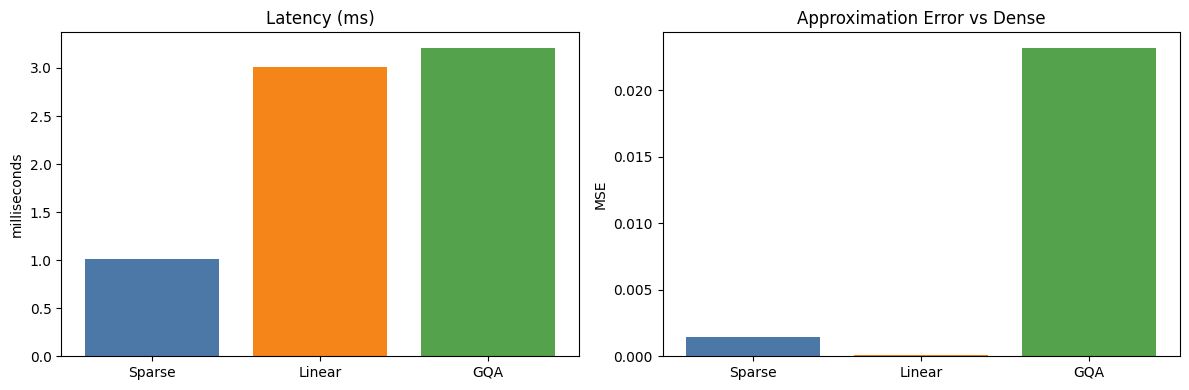

In [9]:
names = ["Sparse", "Linear", "GQA"]
latency = [metrics["sparse_ms"], metrics["linear_ms"], metrics["gqa_ms"]]
mse = [metrics["sparse_mse_vs_dense"], metrics["linear_mse_vs_dense"], metrics["gqa_mse_vs_dense"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, latency, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Latency (ms)")
axes[0].set_ylabel("milliseconds")

axes[1].bar(names, mse, color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("Approximation Error vs Dense")
axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.show()

## 10) Summary
- Reused shared text tokenization and preprocessing helpers for consistent inputs.
- Benchmarked advanced attention variants in NumPy with one shared QKV projection.
- Reported latency and approximation error relative to dense attention.